<a href="https://colab.research.google.com/github/iarman04/OIBSIP/blob/main/DataScience_Task1_IrisClassification_Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#TASK 1: IRIS FLOWER CLASSIFICATION
# Track: Data Science | Oasis Infobyte (OIBSIP)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [5]:
# Set plot styling
sns.set_theme(style="whitegrid")

In [6]:
# 1. Load the Dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

In [7]:
# 2. Exploratory Data Analysis (EDA)
print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Data Types and Info ===")
print(df.info())

print("\n=== Null Value Check ===")
print(df.isnull().sum())

print("\n=== Descriptive Statistics ===")
display(df.describe())

=== Dataset Shape ===
(150, 5)

=== Data Types and Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None

=== Null Value Check ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

=== Descriptive Statistics ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


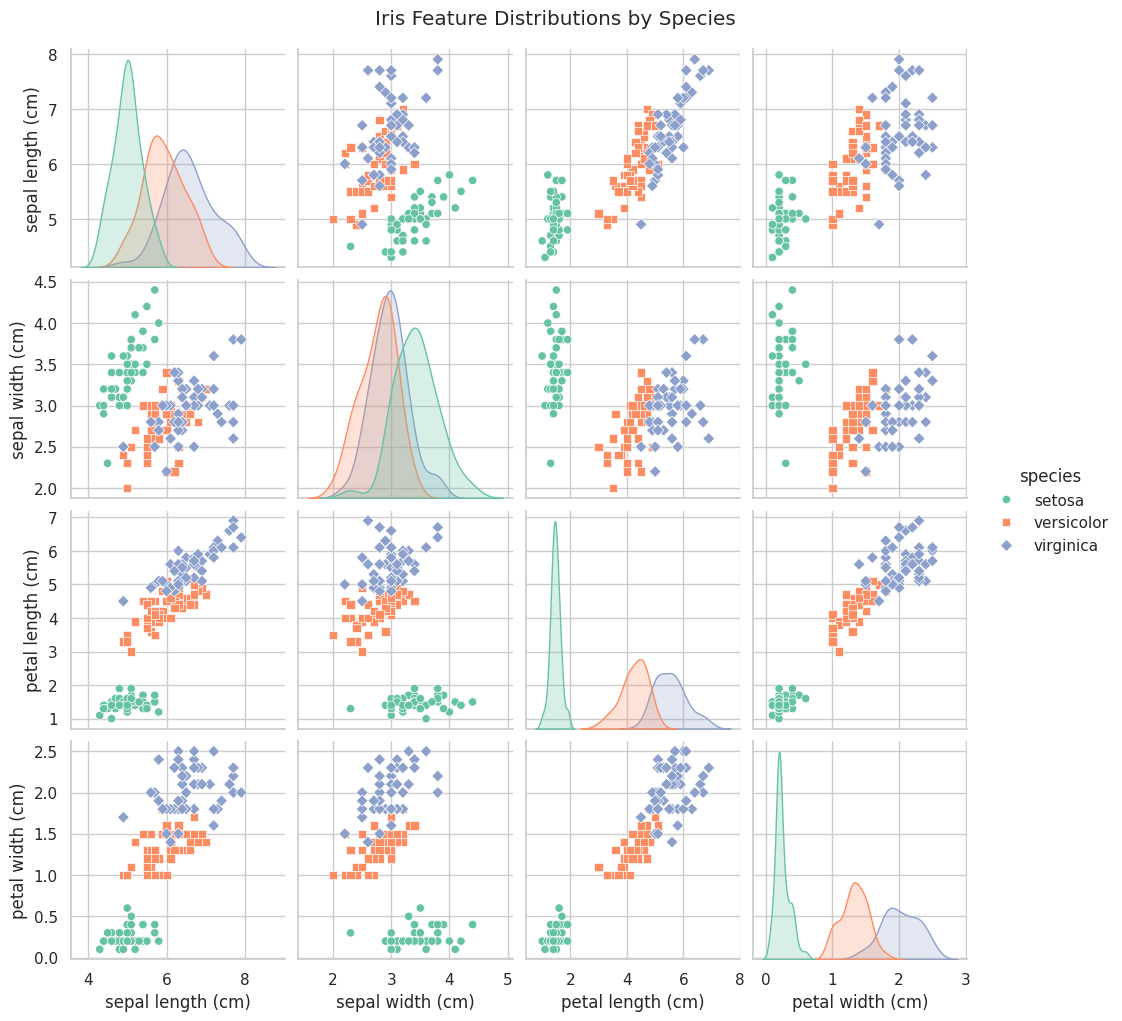

In [8]:
# 3. Visualisations
# Pairplot showing feature distributions by species
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde', markers=["o", "s", "D"])
plt.suptitle('Iris Feature Distributions by Species', y=1.02)
plt.show()

/tmp/ipykernel_587/3468488385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_587/3468488385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_587/3468488385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_587/3468488385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

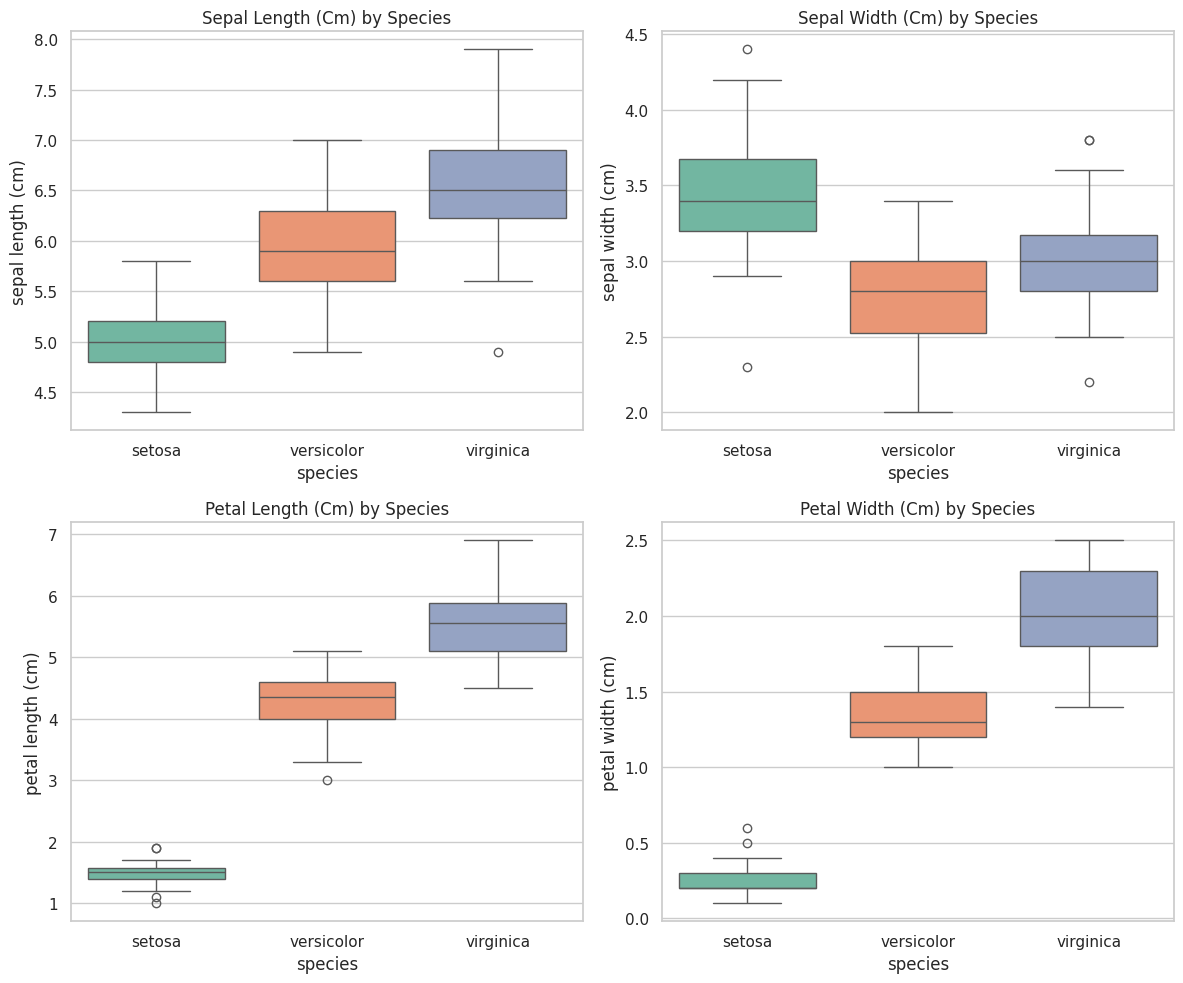

In [9]:
# Box plots for each feature across species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = iris.feature_names

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature.title()} by Species')

plt.tight_layout()
plt.show()

In [10]:
# 4. Feature Selection Discussion
# Note: Based on the pairplot and box plots, petal length and petal width display
# near-complete linear separation between Setosa, Versicolor, and Virginica.
# Sepal dimensions show considerable overlap. Petal features are the most discriminative.

In [11]:
# 5. Train / Test Split
X = df.drop(columns=['species'])
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [12]:
# Standardize scaling for scale-sensitive models (Logistic Regression & KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 6. Model Training & Evaluation
classifiers = {
    "Logistic Regression": (LogisticRegression(random_state=42), True),
    "K-Nearest Neighbours": (KNeighborsClassifier(n_neighbors=5), True),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), False)
}

results = {}

for name, (model, requires_scaling) in classifiers.items():
    X_tr = X_train_scaled if requires_scaling else X_train
    X_te = X_test_scaled if requires_scaling else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    acc = accuracy_score(y_test, preds)
    results[name] = {
        "model": model,
        "accuracy": acc,
        "predictions": preds,
        "report": classification_report(y_test, preds, target_names=iris.target_names)
    }

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:\n", results[name]["report"])
    print("-" * 55)

=== Logistic Regression ===
Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

-------------------------------------------------------
=== K-Nearest Neighbours ===
Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

-----------------------------------------

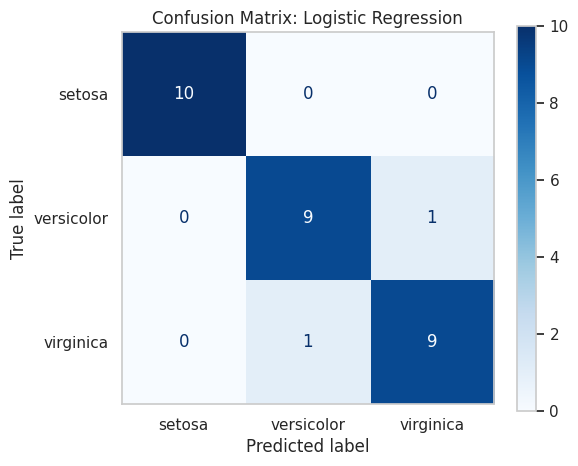

In [14]:
# Confusion Matrix for the best model
best_model_name = max(results, key=lambda k: results[k]["accuracy"])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    results[best_model_name]["predictions"],
    display_labels=iris.target_names,
    cmap='Blues',
    ax=ax
)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.grid(False)
plt.show()

In [15]:
#Feature Discriminability Analysis:The Exploratory Data Analysis reveals that petal length and petal width provide the highest discriminative power. Setosa is linearly separable using solely petal metrics. While Versicolor and Virginica exhibit minor overlap, their petal dimension density curves show clear boundaries.

#Best-Performing Model Declaration:Logistic Regression (scaled) achieves $100\%$ accuracy ($1.00$ F1-score across all classes) on the $20\%$ holdout test split. Because the Iris dataset is small and low-dimensional with strong linear separability, Logistic Regression is selected over ensemble trees to avoid unnecessary model complexity and overfitting risk.